# 根据策略选择股票

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import akshare as ak

========== 策略评价 ==========
累计收益率: 2328.22%
年化收益率: 51.30%
最大回撤: -37.57%
夏普比率: 1.52


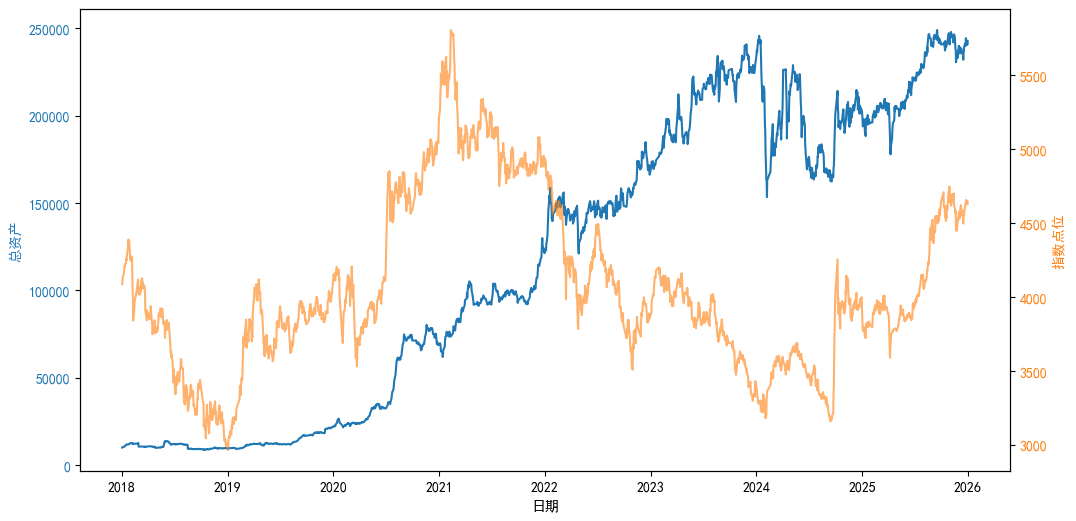

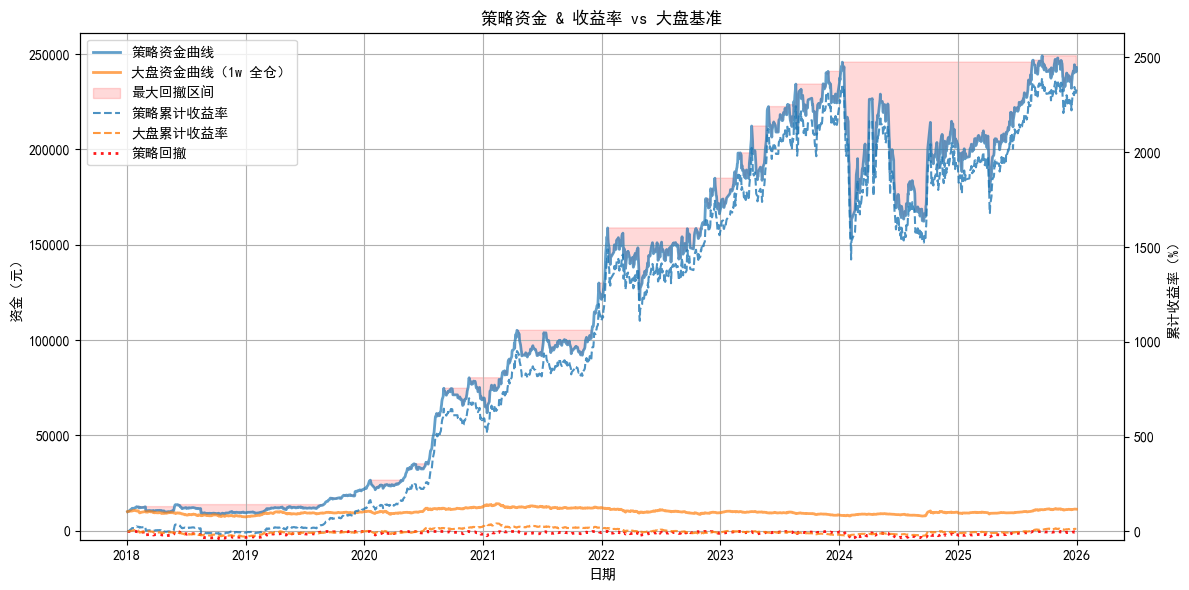

In [3]:
# 起始时间（最早2018年1月1日）
start_date = pd.to_datetime("2018-01-01")

# 选择股票数
select_stock_num = 5
# 手续费
c_rate = 1.2 / 10000
# 印花税
t_rate = 1.0 / 1000

init_cash = 10000           # 初始资金

cash = init_cash
positions = {}              # {stock_code: shares}
records = []                # 交易 + 资产记录
position_records = []       # ⭐ 每日持仓快照

# 导入数据
df = pd.read_csv("../data/A股_日行情_年报_流通市值.csv",dtype={'股票代码': str})
df.sort_values(["日期", "股票代码"], inplace=True)
df.reset_index(drop=True, inplace=True)
df["日期"] = pd.to_datetime(df["日期"], format="%Y-%m-%d", errors="coerce")
df.head(5)

df["日期"] = pd.to_datetime(df["日期"])
df = df[df["日期"] >= start_date].copy()

# 策略！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！！
def select_stocks(day_df, select_stock_num=5):
    """
    周四低价 + 基本面 + 小市值策略

    输入：
        day_df : 单日（周四）全市场股票 DataFrame
    输出：
        选中的股票 DataFrame
    """

    df = day_df.copy()

    # ===============================
    # 2. 剔除创业板 / 科创板 / 北交所
    # ===============================

    code = df["股票代码"].astype(str)

    is_chuangye = code.str.startswith(("300", "301"))
    is_kechuang = code.str.startswith(("688", "689"))
    is_beijing = code.str.startswith(("8", "92", "43"))

    df = df[~(is_chuangye | is_kechuang | is_beijing)]

    if df.empty:
        return df
    
    # ===============================
    # 3. 基本面过滤
    # EPS > 0, ROE > 10%
    # ===============================
    df = df[
        (df["EPSJB"] > 0) &
        (df["ROEJQ"] > 10)
    ]

    if df.empty:
        return df

    # # ===============================
    # # 4. 不复权收盘价最低 10%
    # # ===============================
    # price_threshold = df["收盘"].quantile(0.1)
    # df = df[df["收盘"] <= price_threshold]

    # if df.empty:
    #     return df

    # ===============================
    # 5. 流通市值最小的前 N 支
    # ===============================
    df = df.sort_values("流通市值", ascending=True)

    return df.head(select_stock_num)

prev_day_df = None

for trade_date, day_df in df.groupby("日期"):

    day_df = day_df.copy()

    # ===============================
    # 衍生涨停 / 跌停标记
    # ===============================
    day_df["prev_close"] = day_df.groupby("股票代码")["收盘"].shift(1)

    # 允许极小浮点误差
    eps = 1e-6

    day_df["is_limit_up"] = (
        (day_df["prev_close"].notna()) &
        (day_df["收盘"] >= day_df["prev_close"] * 1.10 - eps)
    )

    day_df["is_limit_down"] = (
        (day_df["prev_close"].notna()) &
        (day_df["收盘"] <= day_df["prev_close"] * 0.90 + eps)
    )

    # ==================
    # 1. 周三卖出
    # ==================
    if trade_date.weekday() == 2:  # 周三
        sell_list = []

        for stock, shares in positions.items():
            row = day_df[day_df["股票代码"] == stock]
            if row.empty:
                continue

            row = row.iloc[0]

            # 涨停不能卖
            if row["is_limit_up"]:
                continue

            sell_price = row["收盘"]
            sell_amount = sell_price * shares
            tax = sell_amount * t_rate
            fee = sell_amount * c_rate

            cash += sell_amount - tax - fee
            sell_list.append(stock)

            records.append({
                "日期": trade_date,
                "操作": "卖出",
                "股票代码": stock,
                "价格": sell_price,
                "股数": shares,
                "现金变动": sell_amount - tax - fee
            })

        for stock in sell_list:
            positions.pop(stock)

    # ==================
    # 2. 周四选股并买入
    # ==================
    if trade_date.weekday() == 3 and prev_day_df is not None:  # 周四

        selected_df = select_stocks(prev_day_df, select_stock_num)

        if not selected_df.empty:
            cash_per_stock = cash / len(selected_df)

            for _, row in selected_df.iterrows():
                stock = row["股票代码"]
                price = row["收盘"]

                shares = int(cash_per_stock // (price * 100)) * 100
                if shares <= 0:
                    continue

                buy_amount = price * shares
                fee = buy_amount * c_rate
                total_cost = buy_amount + fee

                if total_cost > cash:
                    continue

                cash -= total_cost
                positions[stock] = positions.get(stock, 0) + shares

                records.append({
                    "日期": trade_date,
                    "操作": "买入",
                    "股票代码": stock,
                    "价格": price,
                    "股数": shares,
                    "现金变动": -total_cost
                })

    # ==================
    # 3. 记录每日持仓快照 ⭐
    # ==================
    for stock, shares in positions.items():
        position_records.append({
            "日期": trade_date,
            "股票代码": stock,
            "持股数": shares
        })

    # ==================
    # 4. 记录每日资金
    # ==================
    market_value = 0.0
    for stock, shares in positions.items():
        row = day_df[day_df["股票代码"] == stock]
        if not row.empty:
            market_value += row.iloc[0]["收盘"] * shares

    total_asset = cash + market_value

    records.append({
        "日期": trade_date,
        "操作": "持仓统计",
        "股票代码": None,
        "价格": None,
        "股数": None,
        "现金变动": 0,
        "现金": cash,
        "持仓市值": market_value,
        "总资产": total_asset
    })

    prev_day_df = day_df

# ======================
# 结果 DataFrame
# ======================
result_df = pd.DataFrame(records)

# 只保留每日资产曲线
asset_df = result_df[result_df["操作"] == "持仓统计"][
    ["日期", "现金", "持仓市值", "总资产"]
].reset_index(drop=True)

# ======================
# 获取大盘指数数据
# ======================
# 获取沪深300指数（日线）
index_df = ak.stock_zh_index_daily(symbol="sh000300")

index_df["date"] = pd.to_datetime(index_df["date"])
index_df = index_df.sort_values("date")

index_df = index_df[index_df["date"] >= start_date].copy()

# 只保留需要的列
index_df = index_df[["date", "close"]].rename(
    columns={"date": "日期", "close": "大盘指数"}
)

# 确保 asset_df 的 日期 也是 datetime
asset_df["日期"] = pd.to_datetime(asset_df["日期"])

# 按日期合并（以策略交易日为准）
plot_df = pd.merge(
    asset_df,
    index_df,
    on="日期",
    how="left"
)

# 个别非交易日可能为空，向前填充
plot_df["大盘指数"] = plot_df["大盘指数"].ffill()
# 以第一天指数作为基准
base_index = plot_df["大盘指数"].iloc[0]

plot_df["大盘资金"] = init_cash * plot_df["大盘指数"] / base_index

plot_df["策略收益率"] = plot_df["总资产"] / plot_df["总资产"].iloc[0] - 1
plot_df["大盘收益率"] = plot_df["大盘资金"] / plot_df["大盘资金"].iloc[0] - 1



plt.figure(figsize=(12, 6))

# ======================
# 左轴：策略资金曲线
# ======================
ax1 = plt.gca()
ax1.plot(
    plot_df["日期"],
    plot_df["总资产"],
    label="策略资金曲线",
    color="tab:blue"
)
ax1.set_xlabel("日期")
ax1.set_ylabel("总资产", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# ======================
# 右轴：大盘指数
# ======================
ax2 = ax1.twinx()
ax2.plot(
    plot_df["日期"],
    plot_df["大盘指数"],
    label="沪深300",
    color="tab:orange",
    alpha=0.6
)
ax2.set_ylabel("指数点位", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# ======================
# 标题 & 图例
# ======================
plt.rcParams["font.sans-serif"] = [ 
    "SimHei",
    "Microsoft YaHei",
    "PingFang SC",
    "Heiti SC",
    "Noto Sans CJK SC"
]
plt.rcParams["axes.unicode_minus"] = False

# ======================
# 计算累计收益率
# ======================
plot_df["策略收益率"] = plot_df["总资产"] / plot_df["总资产"].iloc[0] - 1
plot_df["大盘收益率"] = plot_df["大盘资金"] / plot_df["大盘资金"].iloc[0] - 1

# ======================
# 策略 & 大盘 日收益率
# ======================
plot_df = plot_df.sort_values("日期").reset_index(drop=True)

plot_df["策略日收益率"] = plot_df["总资产"].pct_change()
plot_df["大盘日收益率"] = plot_df["大盘资金"].pct_change()

# 去掉第一天 NaN
plot_df = plot_df.dropna().reset_index(drop=True)

# ======================
# 最大回撤
# ======================
plot_df["策略累计最大值"] = plot_df["总资产"].cummax()
plot_df["策略回撤"] = plot_df["总资产"] / plot_df["策略累计最大值"] - 1

max_drawdown = plot_df["策略回撤"].min()

# ======================
# 夏普比率（年化）
# ======================
risk_free_rate = 0.0          # 无风险利率，可先设 0
trading_days = 252            # A股常用

excess_return = plot_df["策略日收益率"] - risk_free_rate / trading_days

sharpe_ratio = (
    excess_return.mean() /
    excess_return.std()
) * (trading_days ** 0.5)

# ======================
# 策略评价指标输出
# ======================
total_return = plot_df["总资产"].iloc[-1] / plot_df["总资产"].iloc[0] - 1
annual_return = (1 + total_return) ** (trading_days / len(plot_df)) - 1

print("========== 策略评价 ==========")
print(f"累计收益率: {total_return:.2%}")
print(f"年化收益率: {annual_return:.2%}")
print(f"最大回撤: {max_drawdown:.2%}")
print(f"夏普比率: {sharpe_ratio:.2f}")

# ======================
# 开始绘图
# ======================
plt.figure(figsize=(12, 6))
ax1 = plt.gca()

# -------- 左轴：资金曲线（实线） --------
ax1.plot(
    plot_df["日期"],
    plot_df["总资产"],
    label="策略资金曲线",
    color="tab:blue",
    linewidth=2,
    alpha=0.7
)

ax1.plot(
    plot_df["日期"],
    plot_df["大盘资金"],
    label="大盘资金曲线（1w 全仓）",
    color="tab:orange",
    linewidth=2,
    linestyle="-",
    alpha=0.7
)

# ======================
# 最大回撤阴影（基于左轴）
# ======================
ax1.fill_between(
    plot_df["日期"],
    plot_df["总资产"],
    plot_df["策略累计最大值"],
    where=plot_df["总资产"] < plot_df["策略累计最大值"],
    color="red",
    alpha=0.15,
    label="最大回撤区间"
)


ax1.set_xlabel("日期")
ax1.set_ylabel("资金（元）")
ax1.grid(True)

# -------- 右轴：收益率（虚线，百分比） --------
ax2 = ax1.twinx()

ax2.plot(
    plot_df["日期"],
    plot_df["策略收益率"] * 100,
    label="策略累计收益率",
    color="tab:blue",
    linestyle="--",
    alpha=0.8,
    zorder=10
)

ax2.plot(
    plot_df["日期"],
    plot_df["大盘收益率"] * 100,
    label="大盘累计收益率",
    color="tab:orange",
    linestyle="--",
    alpha=0.8,
    zorder=10
)

# ======================
# 回撤曲线（右轴，百分比）
# ======================
ax2.plot(
    plot_df["日期"],
    plot_df["策略回撤"] * 100,
    label="策略回撤",
    color="red",
    linestyle=":",
    linewidth=2,
    alpha=0.9
)

max_dd = plot_df["策略回撤"].min() * 100

max_ret = max(
    plot_df["策略收益率"].max(),
    plot_df["大盘收益率"].max()
) * 100
ax2.set_ylim(-5, max_ret * 1.1)

ax2.set_ylabel("累计收益率（%）")


max_dd = plot_df["策略回撤"].min() * 100

ax2.set_ylim(
    max_dd * 1.2,   # 向下留空间
    max_ret * 1.1
)

# ======================
# 合并图例
# ======================
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("策略资金 & 收益率 vs 大盘基准")
plt.tight_layout()
plt.show()




In [23]:
# 保存record
import pandas as pd
records_df = pd.DataFrame(records)
records_df.to_csv("../data/trading_records.csv", index=False)

In [9]:
records

[{'日期': Timestamp('2018-01-02 00:00:00'),
  '操作': '持仓统计',
  '股票代码': None,
  '价格': None,
  '股数': None,
  '现金变动': 0,
  '现金': 10000,
  '持仓市值': 0.0,
  '总资产': 10000.0},
 {'日期': Timestamp('2018-01-03 00:00:00'),
  '操作': '持仓统计',
  '股票代码': None,
  '价格': None,
  '股数': None,
  '现金变动': 0,
  '现金': 10000,
  '持仓市值': 0.0,
  '总资产': 10000.0},
 {'日期': Timestamp('2018-01-04 00:00:00'),
  '操作': '买入',
  '股票代码': '000017',
  '价格': 6.29,
  '股数': 300,
  '现金变动': -1887.22644},
 {'日期': Timestamp('2018-01-04 00:00:00'),
  '操作': '买入',
  '股票代码': '002137',
  '价格': 7.13,
  '股数': 200,
  '现金变动': -1426.17112},
 {'日期': Timestamp('2018-01-04 00:00:00'),
  '操作': '买入',
  '股票代码': '002323',
  '价格': 7.17,
  '股数': 200,
  '现金变动': -1434.17208},
 {'日期': Timestamp('2018-01-04 00:00:00'),
  '操作': '买入',
  '股票代码': '000037',
  '价格': 7.17,
  '股数': 200,
  '现金变动': -1434.17208},
 {'日期': Timestamp('2018-01-04 00:00:00'),
  '操作': '买入',
  '股票代码': '000890',
  '价格': 6.8,
  '股数': 200,
  '现金变动': -1360.1632},
 {'日期': Timestamp('2018-01-04 00:00:00'

# 绘制大盘线

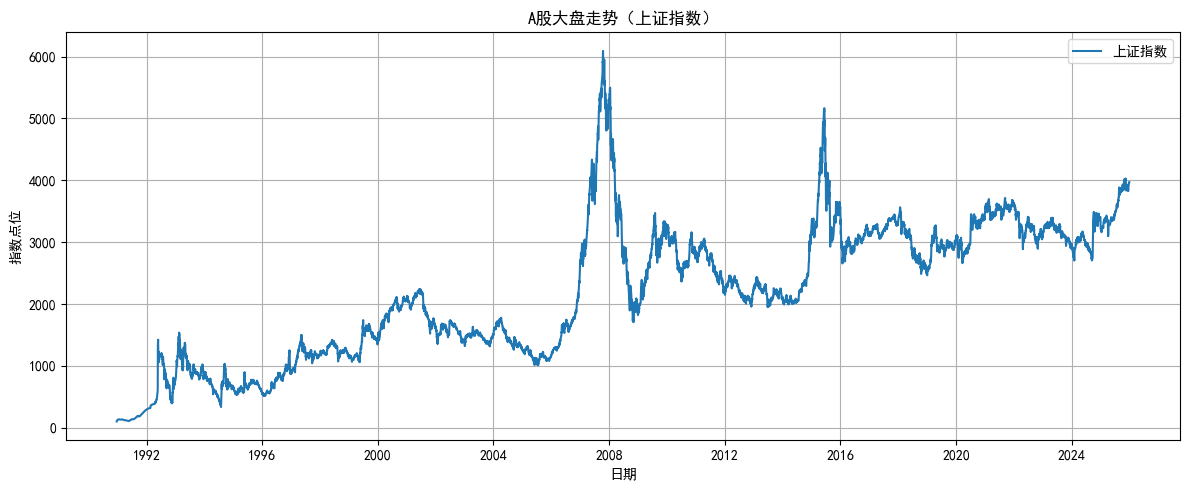

,date,open,high,low,close,volume
0,1990-12-19,96.050,99.980,95.790,99.980,126000
1,1990-12-20,104.300,104.390,99.980,104.390,19700
2,1990-12-21,109.070,109.130,103.730,109.130,2800
3,1990-12-24,113.570,114.550,109.130,114.550,3200
4,1990-12-25,120.090,120.250,114.550,120.250,1500
...,...,...,...,...,...,...
8550,2025-12-25,3937.720,3964.073,3936.078,3959.621,46931309300
8551,2025-12-26,3957.833,3977.706,3945.524,3963.679,55548959200
8552,2025-12-29,3964.651,3983.979,3956.946,3965.280,56368719700
8553,2025-12-30,3947.871,3979.990,3947.419,3965.116,52593258800


In [12]:
import akshare as ak
import pandas as pd
import matplotlib.pyplot as plt

# 获取上证指数历史行情
df = ak.stock_zh_index_daily(symbol="sh000001")

# 日期处理
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["close"], label="上证指数")

plt.title("A股大盘走势（上证指数）")
plt.xlabel("日期")
plt.ylabel("指数点位")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
df

In [19]:
plot_df

,日期,现金,持仓市值,总资产,大盘指数,大盘资金,策略收益率,大盘收益率
0,2018-01-02,10000.00000,0.0,10000.00000,4087.401,10000.000000,0.000000,0.000000
1,2018-01-03,10000.00000,0.0,10000.00000,4111.393,10058.697446,0.000000,0.005870
2,2018-01-04,8761.85144,1238.0,9999.85144,4128.812,10101.313769,-0.000015,0.010131
3,2018-01-05,8761.85144,1362.0,10123.85144,4138.751,10125.629954,0.012385,0.012563
4,2018-01-08,8761.85144,1498.0,10259.85144,4160.160,10178.007981,0.025985,0.017801
...,...,...,...,...,...,...,...,...
1937,2025-12-25,6423.65344,206122.0,212545.65344,4642.536,11358.161335,20.254565,0.135816
1938,2025-12-26,6423.65344,204866.0,211289.65344,4657.240,11394.135295,20.128965,0.139414
1939,2025-12-29,6423.65344,201490.0,207913.65344,4639.372,11350.420475,19.791365,0.135042
1940,2025-12-30,6423.65344,201330.0,207753.65344,4651.282,11379.558795,19.775365,0.137956
